In [30]:
!pip install pandas plotly

In [31]:
import pandas as pd
df=pd.read_csv("OneDrive - The University of Southern Mississippi/hypoxia_casts_2026-02-24.csv")
df.head()

,cast_label,start_time_utc,latitude,longitude,max_depth_reached_m,data_points,profile_hypoxia_detected,profile_hypoxia_min_depth_m,profile_hypoxia_max_depth_m,profile_hypoxia_thickness_m,bottom_hypoxia_detected,bottom_hypoxia_min_depth_m,bottom_hypoxia_max_depth_m,bottom_hypoxia_thickness_m,do_at_max_depth_mgl,salinity_at_max_depth_psu,do_at_max_depth_umolL
0,SN-10 Cast ka82zm,2024-07-21T02:08:05.000Z,29.009193,-89.750071,39.15661,1611,NO,NaN,NaN,NaN,NO,NaN,NaN,NaN,3.08,NaN,96.2500
1,SN-10 Cast 6h9rx,2024-07-21T05:13:00.000Z,29.012156,-89.753135,38.44471,1291,NO,NaN,NaN,NaN,NO,NaN,NaN,NaN,3.05,NaN,95.3125
2,SN-10 Cast 1iujww,2024-07-21T07:10:05.000Z,29.009685,-89.748999,40.15175,1374,NO,NaN,NaN,NaN,NO,NaN,NaN,NaN,2.52,NaN,78.7500
3,SN-10 Cast 2zib84,2024-07-21T09:03:30.000Z,29.010242,-89.748079,40.15197,1368,NO,NaN,NaN,NaN,NO,NaN,NaN,NaN,2.94,NaN,91.8750
4,SN-10 Cast bddybg,2024-07-21T11:05:05.000Z,29.008371,-89.749513,40.51136,1277,NO,NaN,NaN,NaN,NO,NaN,NaN,NaN,2.86,NaN,89.3750


In [32]:
df.columns

Index(['cast_label', 'start_time_utc', 'latitude', 'longitude',
       'max_depth_reached_m', 'data_points', 'profile_hypoxia_detected',
       'profile_hypoxia_min_depth_m', 'profile_hypoxia_max_depth_m',
       'profile_hypoxia_thickness_m', 'bottom_hypoxia_detected',
       'bottom_hypoxia_min_depth_m', 'bottom_hypoxia_max_depth_m',
       'bottom_hypoxia_thickness_m', 'do_at_max_depth_mgl',
       'salinity_at_max_depth_psu', 'do_at_max_depth_umolL'],
      dtype='object')

In [33]:
import plotly.express as px

fig = px.scatter(
    df,
    x="longitude",
    y="latitude",
    color="do_at_max_depth_mgl",
    size="max_depth_reached_m",
    hover_name="cast_label",
    title="Dissolved Oxygen at Max Depth by Location",
    color_continuous_scale= "RdYlGn",
    range_color=[0.01,5],
    height=700,
    width=1250
    )
fig.show()

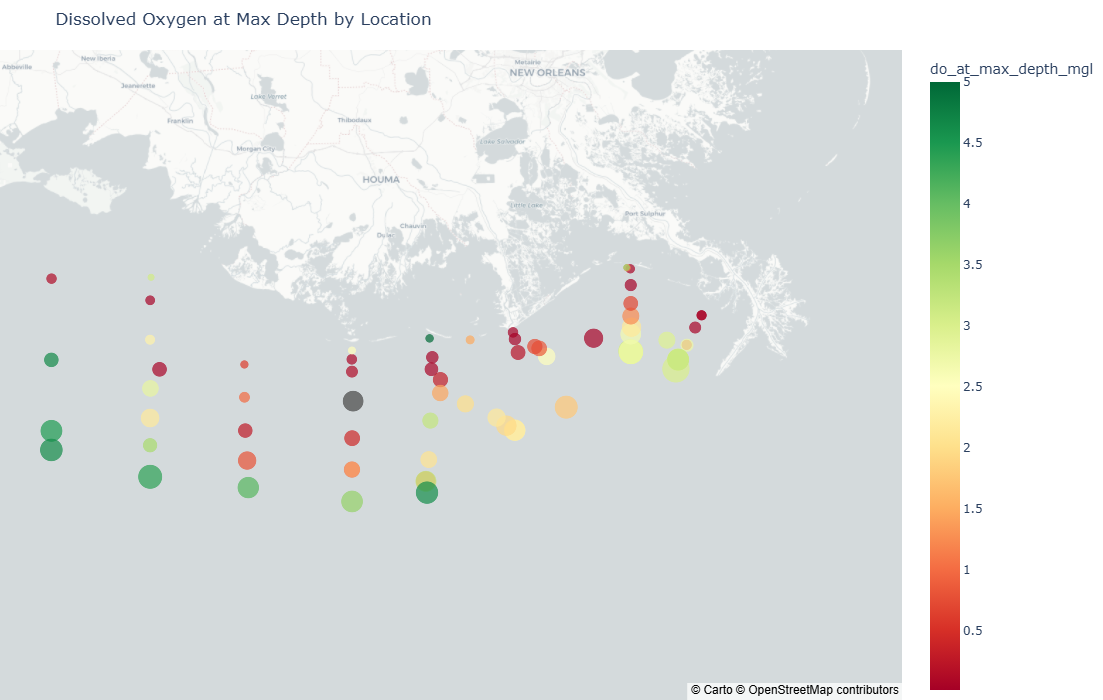

In [53]:
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="do_at_max_depth_mgl",
    size="max_depth_reached_m",
    hover_name="cast_label",
    title="Dissolved Oxygen at Max Depth by Location",
    color_continuous_scale="RdYlGn",
    range_color=[0.01, 5],
    zoom=7.5,
    height=700,
    width=1250
)

fig.update_layout(
    mapbox_style="carto-positron",  # or "carto-darkmatter"
    mapbox_center={
        "lat": df["latitude"].mean(),
        "lon": df["longitude"].mean()
    },
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

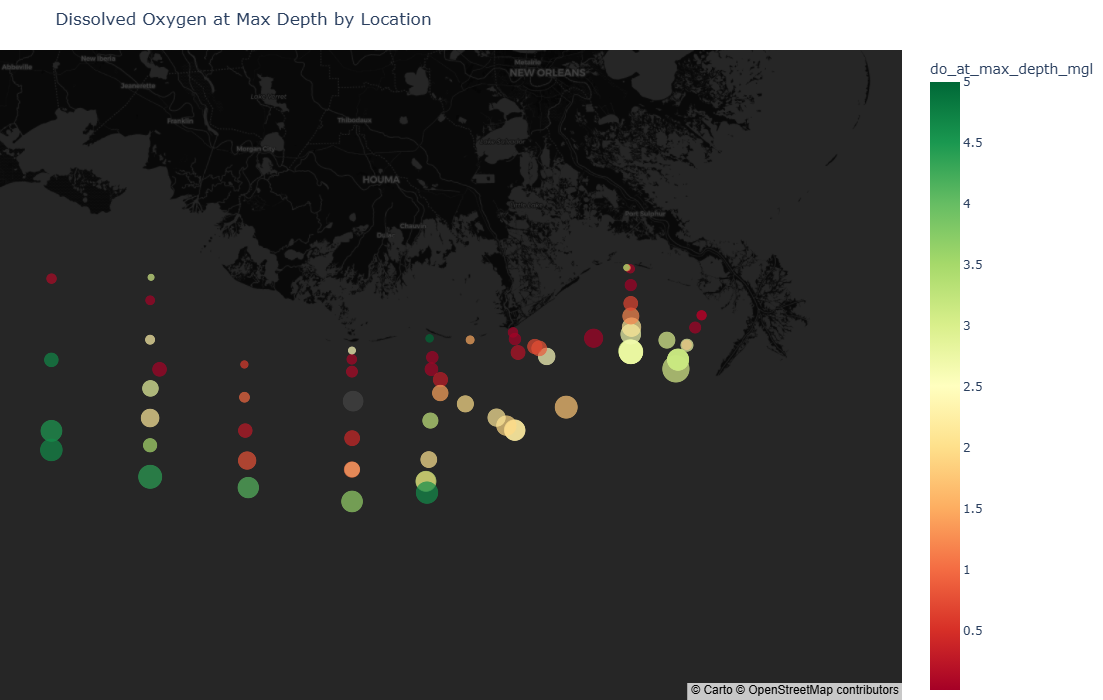

In [54]:
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="do_at_max_depth_mgl",
    size="max_depth_reached_m",
    hover_name="cast_label",
    title="Dissolved Oxygen at Max Depth by Location",
    color_continuous_scale="RdYlGn",
    range_color=[0.01, 5],
    zoom=7.5,
    height=700,
    width=1100
)

fig.update_layout(
    mapbox_style="carto-darkmatter", 
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

In [36]:
import plotly.express as px

df["profile_hypoxia_detected"] = df["profile_hypoxia_detected"].str.strip().str.upper()

counts = df["profile_hypoxia_detected"].value_counts().reset_index()
counts.columns = ["Hypoxia Status", "Count"]

fig = px.bar(
    counts,
    x="Hypoxia Status",
    y="Count",
    color="Hypoxia Status",
    title="Number of Casts With and Without Hypoxia",
    width=500,
    height=600,
    color_discrete_map={
        "YES": "red",
        "NO": "green"
    },
    text="Count" 
)

fig.show()

In [37]:
hypoxia_df = df[df["profile_hypoxia_detected"] == "YES"].copy()

fig = px.bar(
    hypoxia_df,
    x="cast_label",
    y="profile_hypoxia_thickness_m",
    color="profile_hypoxia_thickness_m",
    title="Hypoxia Thickness by Cast",
    width=1100,
    height=700,
    color_continuous_scale= "YlOrRd"
)

fig.update_xaxes(tickangle=45)

fig.show()

In [38]:
hypoxia_df = df[df["profile_hypoxia_detected"].str.strip().str.upper() == "YES"].copy()

In [39]:
import plotly.express as px

fig = px.scatter(
    hypoxia_df,
    x="longitude",
    y="latitude",
    color="profile_hypoxia_thickness_m",
    hover_name="cast_label",
    title="Hypoxia Thickness by Location",
    width=1100,
    height=800,
    color_continuous_scale="Reds",
    size_max=20
)

fig.update_traces(marker=dict(size=20))

fig.update_coloraxes(cmin=0, cmax=hypoxia_df["profile_hypoxia_thickness_m"].max())

fig.show()

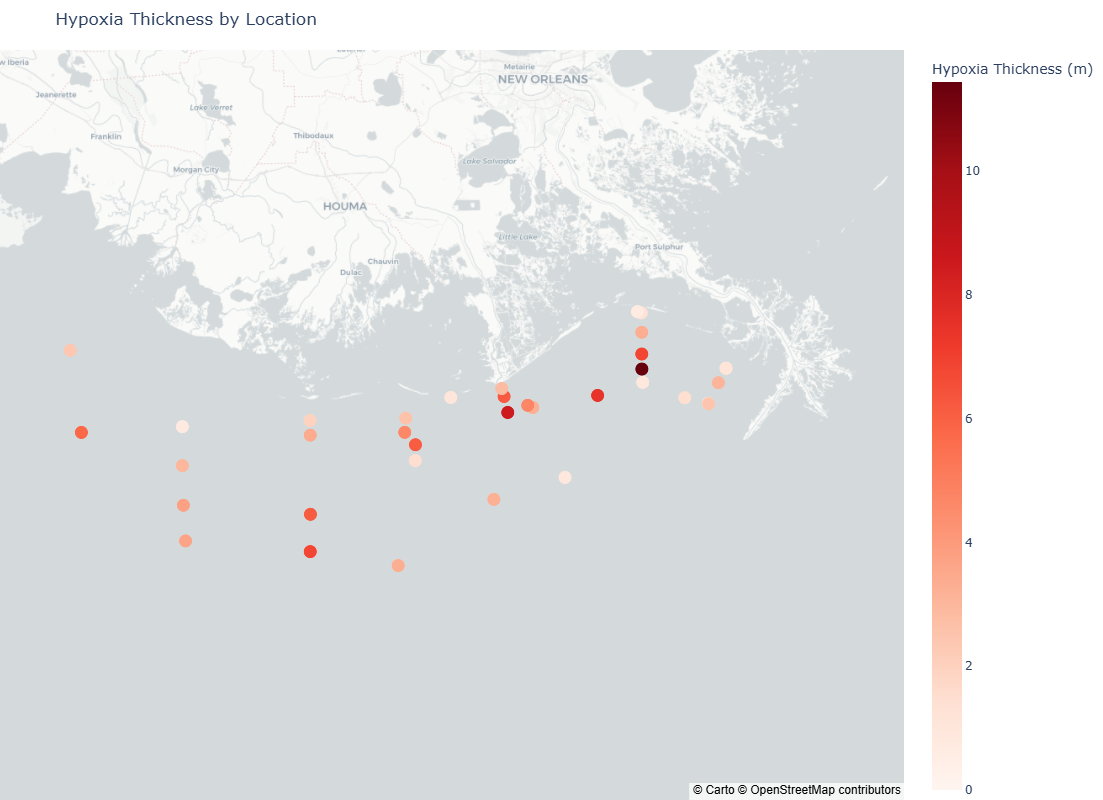

In [55]:
import plotly.express as px

hypoxia_df["thickness_clean"] = hypoxia_df["profile_hypoxia_thickness_m"].fillna(0)

fig = px.scatter_mapbox(
    hypoxia_df,
    lat="latitude",
    lon="longitude",
    color="thickness_clean",
    hover_name="cast_label",
    hover_data=["max_depth_reached_m", "do_at_max_depth_mgl"],
    title="Hypoxia Thickness by Location",
    color_continuous_scale="Reds",
    size_max=30,
    zoom=7.75,
    height=800,
    width=1100,
    labels={
        "thickness_clean": "Hypoxia Thickness (m)"
}
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0, "t":50, "l":0, "b":0}
)
fig.update_traces(marker=dict(size=14))
fig.update_coloraxes(cmin=0, cmax=hypoxia_df["profile_hypoxia_thickness_m"].max())
fig.show()

In [41]:
hypoxia_df = df[df["profile_hypoxia_detected"].str.strip().str.upper() == "YES"].copy()

In [42]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=hypoxia_df["cast_label"],
    y=hypoxia_df["profile_hypoxia_min_depth_m"],
    mode="markers",
    marker=dict(color="red"),
    name="Min Depth (start of hypoxia)"
))

fig.add_trace(go.Scatter(
    x=hypoxia_df["cast_label"],
    y=hypoxia_df["profile_hypoxia_max_depth_m"],
    mode="markers",
    marker=dict(color="darkred"),
    name="Max Depth (end of hypoxia)"
))

# connect them with vertical lines
for i in range(len(hypoxia_df)):
    fig.add_shape(
        type="line",
        x0=hypoxia_df["cast_label"].iloc[i],
        x1=hypoxia_df["cast_label"].iloc[i],
        y0=hypoxia_df["profile_hypoxia_min_depth_m"].iloc[i],
        y1=hypoxia_df["profile_hypoxia_max_depth_m"].iloc[i],
        line=dict(color="Red", width=3)
    )

fig.update_layout(
    title="Hypoxia Depth Range by Cast",
    xaxis_title="Cast",
    yaxis_title="Depth (m)",
    height=700,
    width=1100
)

fig.update_yaxes(autorange="reversed")

fig.show()

In [43]:
fig = px.scatter(
    df,
    x="start_time_utc",
    y="do_at_max_depth_mgl",
    color="profile_hypoxia_detected",
    title="Oxygen Over Time",
    width=1100,
    height=600,
    color_discrete_map={
        "YES": "red",
        "NO": "green"
    }
)

fig.show()

In [44]:
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="do_at_max_depth_mgl",
    hover_name="cast_label",
    hover_data=["start_time_utc", "max_depth_reached_m", "profile_hypoxia_detected"],
    title="Dissolved Oxygen by Location",
    color_continuous_scale="RdYlGn",
    range_color=[0.01, 5],
    zoom=7.5,
    height=800,
    width=1100,
    labels={
        "do_at_max_depth_mgl": "DO at Max Depth (mg/L)"
    }
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.update_traces(marker=dict(size=12))

fig.show()

In [45]:
df["start_time_utc"] = pd.to_datetime(df["start_time_utc"])
df = df.sort_values("start_time_utc")

In [46]:
df[["latitude", "longitude"]].isna().sum()

latitude     0
longitude    0
dtype: int64

In [47]:
df[["latitude", "longitude"]].head()

,latitude,longitude
0,29.009193,-89.750071
1,29.012156,-89.753135
2,29.009685,-89.748999
3,29.010242,-89.748079
4,29.008371,-89.749513


In [48]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df["distance_m"] = haversine(
    df["latitude"].shift(),
    df["longitude"].shift(),
    df["latitude"],
    df["longitude"]
)

df["distance_m"] = df["distance_m"].fillna(0)

df[["cast_label", "start_time_utc", "distance_m"]].head(10)

,cast_label,start_time_utc,distance_m
0,SN-10 Cast ka82zm,2024-07-21 02:08:05+00:00,0.000000
1,SN-10 Cast 6h9rx,2024-07-21 05:13:00+00:00,444.179987
2,SN-10 Cast 1iujww,2024-07-21 07:10:05+00:00,487.034048
3,SN-10 Cast 2zib84,2024-07-21 09:03:30+00:00,108.848281
4,SN-10 Cast bddybg,2024-07-21 11:05:05+00:00,250.405518
5,SN-13 Cast ol3xum,2024-07-21 15:12:10+00:00,30070.122751
6,SN-13 Cast 4um0c,2024-07-21 20:33:28+00:00,25.429696
7,SN-13 Cast rqlx5p,2024-07-21 22:08:43+00:00,5201.378426
8,SN-13 Cast roe8cn,2024-07-22 01:32:31+00:00,7276.953613
9,SN-13 Cast 5mussd,2024-07-22 01:45:10+00:00,167.037413


In [49]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df["distance_m"] = haversine(
    df["latitude"].shift(),
    df["longitude"].shift(),
    df["latitude"],
    df["longitude"]
)

df["distance_m"] = df["distance_m"].fillna(0)

df["total_distance_m"] = df["distance_m"].cumsum()

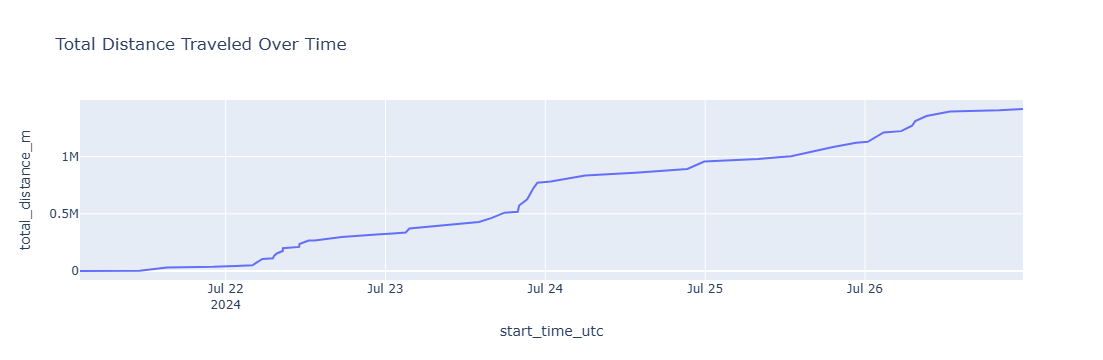

In [50]:
import plotly.express as px

fig = px.line(
    df,
    x="start_time_utc",
    y="total_distance_m",
    title="Total Distance Traveled Over Time"
)

fig.show()